# 02 — Model Training Analysis

Analysis of the XGBoost model training results: cross-validation, ablation study, and feature importance.

**Goals:**
1. Inspect cross-validation stability across folds.
2. Validate the ablation study — which dimensions matter most.
3. Visualize global feature importance.
4. Inspect residuals on the held-out test set.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sys.path.insert(0, str(Path('..').resolve()))
from backend.ml.framework import FRAMEWORK
from backend.ml.train import engineer_features, get_feature_columns

ART = Path('..') / 'backend' / 'ml' / 'artifacts'
with open(ART / 'metrics_report.json') as f:
    metrics = json.load(f)
model = joblib.load(ART / 'xgboost_model.pkl')
feat_cols = json.load(open(ART / 'feature_columns.json'))
importance = pd.read_csv(ART / 'feature_importance.csv')

print('Metrics report keys:', list(metrics.keys()))
print(f"\nTrain size: {metrics['n_train']}, Test size: {metrics['n_test']}, Features: {metrics['n_features']}")

Metrics report keys: ['cv_results', 'ablation_study', 'test_metrics', 'n_train', 'n_test', 'n_features']

Train size: 800, Test size: 200, Features: 45


## Cross-validation results

K = 10 folds
  RMSE: 0.0400 ± 0.0036
  MAE:  0.0285 ± 0.0022
  R²:   0.9949 ± 0.0009


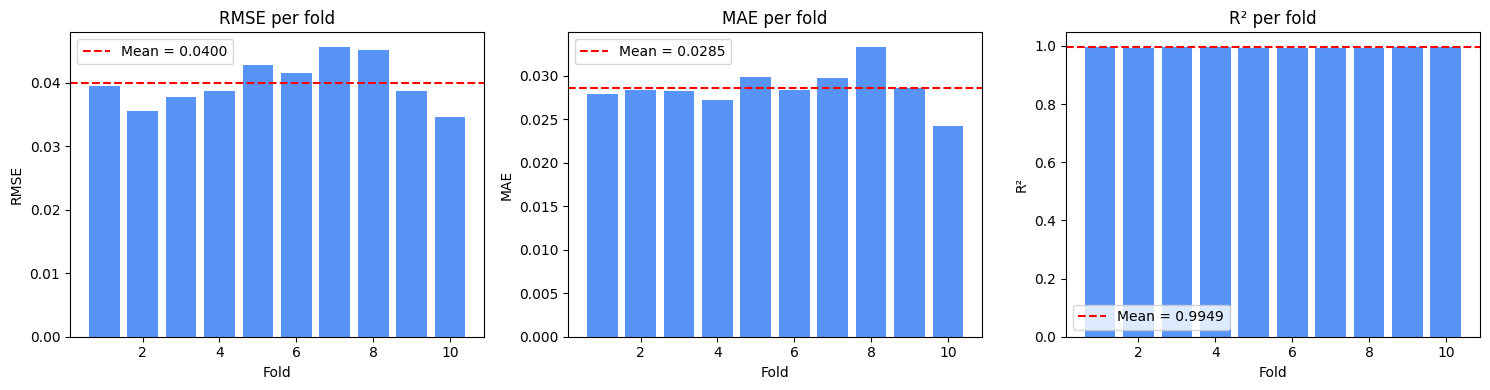

In [2]:
cv = metrics['cv_results']
print(f"K = {cv['k']} folds")
print(f"  RMSE: {cv['rmse']['mean']:.4f} ± {cv['rmse']['std']:.4f}")
print(f"  MAE:  {cv['mae']['mean']:.4f} ± {cv['mae']['std']:.4f}")
print(f"  R²:   {cv['r2']['mean']:.4f} ± {cv['r2']['std']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ['rmse', 'mae', 'r2'], ['RMSE', 'MAE', 'R²']):
    folds = cv[key]['per_fold']
    ax.bar(range(1, len(folds) + 1), folds, color='#3b82f6', alpha=0.85)
    ax.axhline(cv[key]['mean'], color='red', linestyle='--',
               label=f"Mean = {cv[key]['mean']:.4f}")
    ax.set_xlabel('Fold')
    ax.set_ylabel(title)
    ax.set_title(f'{title} per fold')
    ax.legend()
plt.tight_layout()
plt.show()

## Ablation study

We retrain the model after removing each dimension's questions to measure how much that dimension contributes to predictive power.

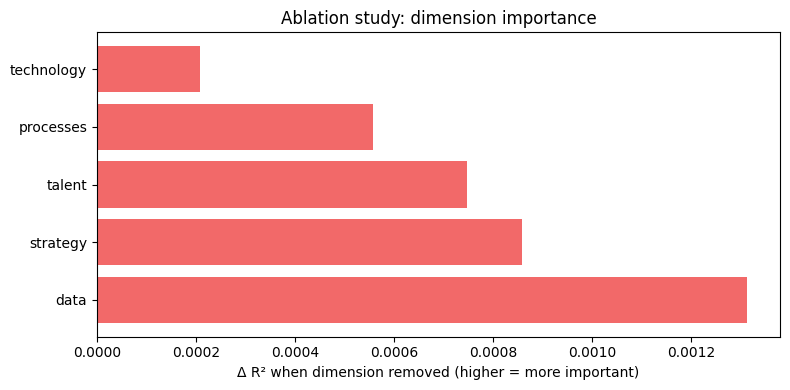

,dimension,r2_without,delta_r2
0,data,0.993547,0.001315
3,strategy,0.994002,0.000860
1,talent,0.994113,0.000748
4,processes,0.994304,0.000558
2,technology,0.994654,0.000208


In [3]:
abl = metrics['ablation_study']
rows = []
for dim_id, res in abl['ablations'].items():
    rows.append({'dimension': dim_id, 'r2_without': res['r2'], 'delta_r2': res['delta_r2']})
abl_df = pd.DataFrame(rows).sort_values('delta_r2', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(abl_df['dimension'], abl_df['delta_r2'], color='#ef4444', alpha=0.8)
ax.set_xlabel('Δ R² when dimension removed (higher = more important)')
ax.set_title('Ablation study: dimension importance')
plt.tight_layout()
plt.show()

abl_df

## Test set performance

In [4]:
test = metrics['test_metrics']
print(f"Held-out test set:")
print(f"  RMSE: {test['rmse']:.4f}")
print(f"  MAE:  {test['mae']:.4f}")
print(f"  R²:   {test['r2']:.4f}")

Held-out test set:
  RMSE: 0.0365
  MAE:  0.0276
  R²:   0.9955


## Feature importance

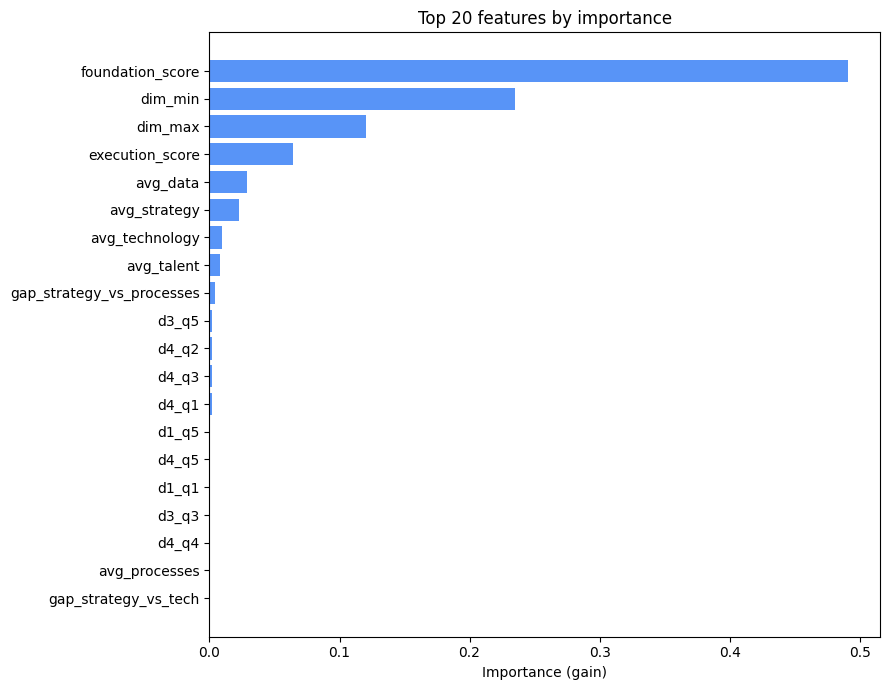

In [5]:
top20 = importance.head(20)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='#3b82f6', alpha=0.85)
ax.set_xlabel('Importance (gain)')
ax.set_title('Top 20 features by importance')
plt.tight_layout()
plt.show()

## Predictions vs actuals on test set

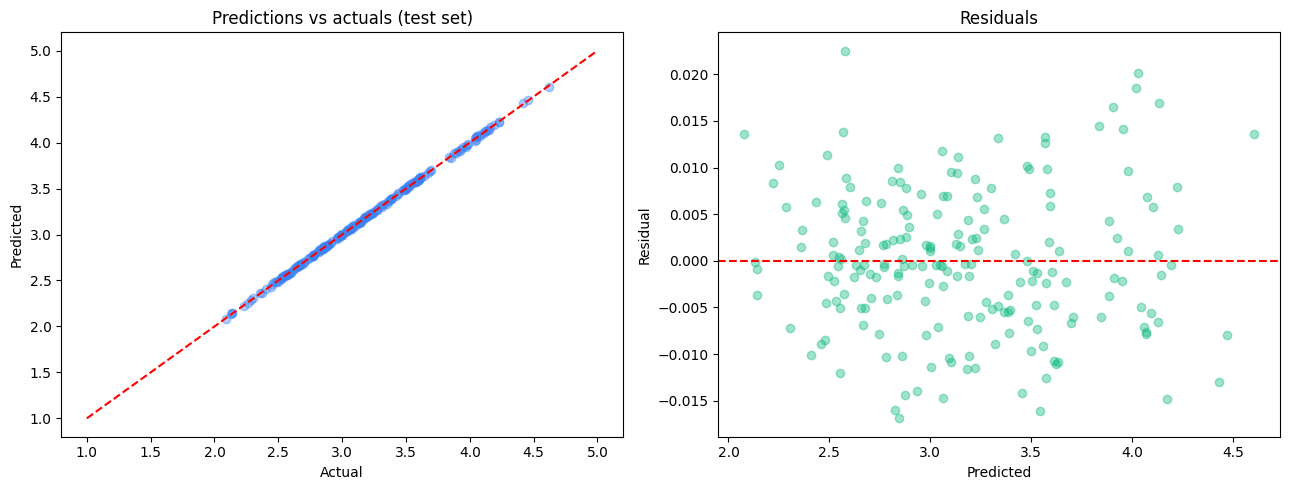

Residual mean: -0.0001 (should be ~0)
Residual std:  0.0076


In [6]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(Path('..') / 'data' / 'synthetic' / 'synthetic_companies.csv')
df_feat = engineer_features(df)
X = df_feat[feat_cols]
y = df_feat['maturity_score']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42, stratify=df_feat['sector'])
preds = model.predict(X_te)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_te, preds, alpha=0.4, color='#3b82f6')
axes[0].plot([1, 5], [1, 5], 'r--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Predictions vs actuals (test set)')

residuals = y_te - preds
axes[1].scatter(preds, residuals, alpha=0.4, color='#10b981')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals')
plt.tight_layout()
plt.show()
print(f'Residual mean: {residuals.mean():.4f} (should be ~0)')
print(f'Residual std:  {residuals.std():.4f}')